In [2]:
import cloudpickle
 
with open("model_SCTMD.pkl", "rb") as f:
    obj = cloudpickle.load(f)

In [3]:
model, exog_names = obj

In [5]:
model.predict()

array([2.59338843, 2.58849595, 2.59107614, ..., 3.3418796 , 3.34142595,
       3.34116638], shape=(289961,))

In [8]:
exog_names

['Current_basis_weight',
 'Starch_uptake__g/m2_',
 'Actual_moisture',
 'Jet/wire_ratio',
 'Draw_PD5-SS',
 'Draw_PD3-PD4',
 'PickUp_Tension',
 'Vacuum_presszone_of_suction-press_roll',
 'Vacuum_suction_box_10',
 'Vacuum_wire_suction_box_1',
 'Top_wire_tenstion',
 'pH_measurement_white_water_B41',
 'Thick_Stock_Consistency__%_',
 'Speed_Size_Press',
 'Rod_Pressure_Bottom_Roll']

In [4]:
import pandas as pd
import numpy as np

df = pd.read_parquet(f"data/costimier_continuous.parquet").set_index("Wedge_Time")
df = df[~df.index.duplicated(keep="first")]
df.loc[:,"Starch_uptake__g/m2_"]=df["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]+df["Starch_uptake_by_paper_Top_Roll__g/m2_"]
transition_mask=df['MBS_Current_reel_ID']!=df['MBS_Current_reel_ID'].shift(-1)
itansition=np.where(transition_mask)[0]

temp=df.loc[transition_mask, "MBS_SCT_MD"]
df["MBS_SCT_MD"]=np.nan
df.loc[transition_mask,"MBS_SCT_MD"]=temp
X = df[exog_names]
y = df["MBS_SCT_MD"]

In [5]:
X_train = df[df.index < "2026-2-1"][exog_names]
y_train = df[df.index < "2026-2-1"]["MBS_SCT_MD"]

X_test = df[(df.index > "2026-2-1") & (df.index < "2026-2-10")][exog_names]
y_test = df[(df.index > "2026-2-1") & (df.index < "2026-2-10")]["MBS_SCT_MD"]

In [12]:
import seaborn as sns 

sns.set(rc={"figure.figsize":(12, 4)})
sns.set_style('whitegrid')
sns.set_context('notebook')

In [13]:
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
preds = []
lower = []
upper = []
 
refit_every = 50
valid_count = 0
 
endog_refit = np.asarray(model.model.data.orig_endog).reshape(-1)
exog_refit = np.asarray(model.model.data.orig_exog) if model.model.data.orig_exog is not None else None
 
model_cls = model.model.__class__
init_kwargs = model.model._get_init_kwds().copy()
 
for i in tqdm(range(len(y_test)), total=len(y_test), desc="Recursive prediction"):
 
    x_row = X_test.iloc[[i]].to_numpy()
    y_true = y_test.iloc[i]
 
    fcst = model.get_forecast(steps=1, exog=x_row)
    y_hat = fcst.predicted_mean[0]
    ci = fcst.conf_int()
 
    preds.append(y_hat)
    lower.append(ci[0, 0])
    upper.append(ci[0, 1])
 
    if pd.notna(y_true):
        y_row = np.array([y_true])
 
        model = model.append(endog=y_row, exog=x_row, refit=False)
 
        endog_refit = np.concatenate([endog_refit, y_row])
        if exog_refit is not None:
            exog_refit = np.vstack([exog_refit, x_row])
 
        valid_count += 1
 
        if valid_count % refit_every == 0:
            print(f"Full refit at index {i}, timestamp {y_test.index[i]}")
 
            refit_mod = model_cls(
                endog=endog_refit,
                exog=exog_refit,
                **init_kwargs
            )
            model = refit_mod.fit(start_params=model.params, disp=False)
 
pred_df = pd.DataFrame(
    {
        "y_true": y_test.values,
        "y_pred": preds,
        "lower": lower,
        "upper": upper,
    },
    index=y_test.index,
)
 
df_eval = pred_df.dropna(subset=["y_true"])
 
rmse = np.sqrt(mean_squared_error(df_eval["y_true"], df_eval["y_pred"]))
mae = mean_absolute_error(df_eval["y_true"], df_eval["y_pred"])
r2 = r2_score(df_eval["y_true"], df_eval["y_pred"])
 
print("N:", len(df_eval))
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
 

Recursive prediction:  21%|██        | 2362/11307 [07:06<13:24, 11.12it/s]  

Full refit at index 2368, timestamp 2026-02-02 19:01:00


Recursive prediction:  21%|██        | 2362/11307 [07:20<13:24, 11.12it/s]c:\workspace\costimiser\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Recursive prediction:  42%|████▏     | 4774/11307 [23:40<07:43, 14.09it/s]   

Full refit at index 4776, timestamp 2026-02-04 12:19:00


Recursive prediction:  66%|██████▌   | 7440/11307 [32:18<02:37, 24.56it/s]   

Full refit at index 7441, timestamp 2026-02-07 04:29:00


Recursive prediction:  88%|████████▊ | 9983/11307 [39:17<01:07, 19.65it/s]  

Full refit at index 9984, timestamp 2026-02-09 01:57:00


Recursive prediction: 100%|██████████| 11307/11307 [45:07<00:00,  4.18it/s]  

N: 227
RMSE: 0.1210737719947157
MAE: 0.09168341209901266
R2: 0.902899226752984


<Axes: xlabel='Wedge_Time', ylabel='y_true'>

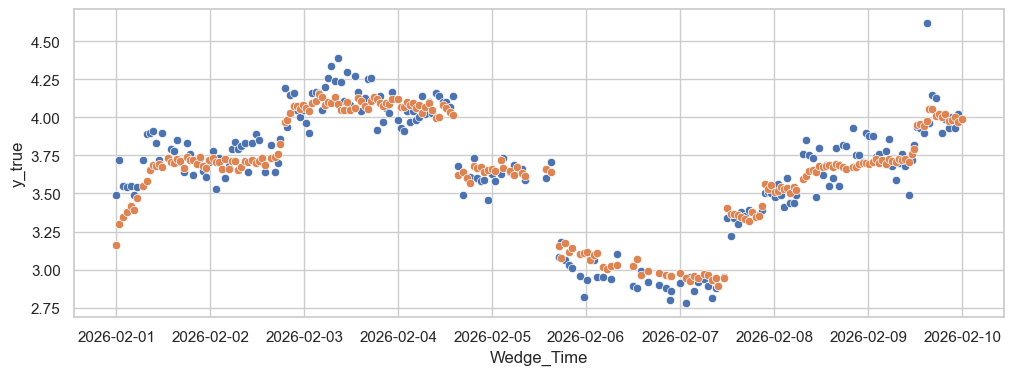

In [15]:
sns.scatterplot(df_eval.reset_index(), x="Wedge_Time", y="y_true")
sns.scatterplot(df_eval.reset_index(), x="Wedge_Time", y="y_pred")

In [14]:
df_eval

,y_true,y_pred,lower,upper
Wedge_Time,,,,
2026-02-01 00:01:00,3.49,3.162203,2.997149,3.327257
2026-02-01 00:39:00,3.72,3.297543,3.139250,3.455835
2026-02-01 01:39:00,3.55,3.347774,3.193351,3.502196
2026-02-01 02:52:00,3.54,3.377178,3.225254,3.529103
2026-02-01 03:42:00,3.55,3.419276,3.269091,3.569462
...,...,...,...,...
2026-02-09 20:34:00,3.93,3.974863,3.828713,4.121012
2026-02-09 21:24:00,4.00,3.981590,3.835440,4.127739
2026-02-09 22:13:00,3.93,4.005514,3.859364,4.151663


In [6]:
res = model

In [9]:
import shap

In [12]:
len(exog_names)

15

In [ ]:
import cloudpickle
 
with open("model_SCTMD.pkl", "rb") as f:
    obj = cloudpickle.load(f)
model, exog_names = obj
    
res = model

# -----------------------------
# 2. Extract coefficients (beta)
# -----------------------------
# Ensure correct order
beta = res.params[2:]

# -----------------------------
# 3. (Optional) intercept
# -----------------------------
# In UCM, intercept is usually part of the state (level),
# so we set it to 0 for the exogenous linear part
intercept = 0.0

# -----------------------------
# 4. Prepare data
# -----------------------------
X_train_exog = X_train[exog_names].copy()
X_test_exog = X_test[exog_names].copy()

# -----------------------------
# 5. Create SHAP LinearExplainer
# -----------------------------
explainer = shap.LinearExplainer(
    model=(beta, intercept), # linear model
    masker=X_train_exog # background data
)

# -----------------------------
# 6. Compute SHAP values
# -----------------------------
shap_values = explainer(X_test_exog)

# -----------------------------
# 7. Outputs
# -----------------------------
# SHAP values as DataFrame
shap_df = pd.DataFrame(
    shap_values.values,
    columns=exog_names,
    index=X_test_exog.index
)

# Base value (expected value)
base_value = explainer.expected_value

# Exogenous prediction
pred_exog = X_test_exog @ beta

# -----------------------------
# 8. (Optional) consistency check
# -----------------------------
reconstructed = base_value + shap_df.sum(axis=1)

print("Check (should be True):",
      np.allclose(reconstructed.values, pred_exog.values))

Check (should be True): True
